# 신종 게임 은어 및 악플 필터링 텍스트 분류기

**전체 파이프라인 (순서대로 실행)**

1. 라이브러리 설치
2. 데이터 로드 & 전처리
3. kcBERT 미세조정 (Fine-Tuning)
4. 평가 & 로컬 저장
5. 예시 문장 테스트
6. Gradio 웹 UI 실행
7. (선택) Hugging Face Hub 업로드


## 1. 라이브러리 설치

In [1]:
%pip install -q torch transformers datasets accelerate evaluate scikit-learn gradio huggingface_hub sentencepiece protobuf


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. 설정

In [2]:
from __future__ import annotations

import numpy as np
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

DATASET_NAME = "smilegate-ai/kor_unsmile"
MODEL_NAME   = "beomi/kcbert-base"   # 한국어 댓글/채팅에 적합한 BERT
OUTPUT_DIR   = "./my-custom-model"
MAX_LENGTH   = 128
NUM_LABELS   = 2
LABEL2ID     = {"정상": 0, "악플": 1}
ID2LABEL     = {0: "정상", 1: "악플"}

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. 데이터 수집 및 전처리

In [3]:
# === 학습 스킵: my-custom-model 로드 모드에서는 불필요 ===
# def to_binary_label(example: dict) -> dict:
#     """
#     kor_unsmile은 다중 라벨(혐오 카테고리 + clean)입니다.
#       - clean == 1  → 정상(0)
#       - 그 외       → 악플(1)
#     """
#     example["label"] = 0 if example["clean"] == 1 else 1
#     return example
#
#
# raw = load_dataset(DATASET_NAME)
#
# dataset = raw.map(to_binary_label)
# dataset = dataset.rename_column("문장", "text")
# dataset = dataset.select_columns(["text", "label"])
#
# print("=== 데이터셋 미리보기 ===")
# print(dataset)
# print(dataset["train"][0])
print("데이터 로드 스킵 (저장된 모델 사용)")

데이터 로드 스킵 (저장된 모델 사용)


## 4. 토크나이징

In [4]:
# === 학습 스킵: my-custom-model 로드 모드에서는 불필요 ===
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
#
#
# def tokenize_function(examples):
#     return tokenizer(
#         examples["text"],
#         truncation=True,
#         padding=False,  # 배치 패딩은 DataCollator가 처리
#         max_length=MAX_LENGTH,
#     )
#
#
# tokenized = dataset.map(
#     tokenize_function,
#     batched=True,
#     remove_columns=["text"],
# )
# print(tokenized)
print("토크나이징 스킵 (저장된 모델 사용)")

토크나이징 스킵 (저장된 모델 사용)


## 5. 모델 로드

In [5]:
# === beomi/kcbert-base 대신 my-custom-model에서 직접 로드 ===
# model = AutoModelForSequenceClassification.from_pretrained(
#     MODEL_NAME,
#     num_labels=NUM_LABELS,
#     id2label=ID2LABEL,
#     label2id=LABEL2ID,
# )
# print(model.config)

model = AutoModelForSequenceClassification.from_pretrained(OUTPUT_DIR)
tokenizer = AutoTokenizer.from_pretrained(OUTPUT_DIR)
print(f"모델 로드 완료: {OUTPUT_DIR}")
print(model.config)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7448.34it/s]

모델 로드 완료: ./my-custom-model
BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForSequenceClassification"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "directionality": "bidi",
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "\uc815\uc0c1",
    "1": "\uc545\ud50c"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "\uc545\ud50c": 1,
    "\uc815\uc0c1": 0
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 300,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "pooler_fc_size": 768,
  "pooler_num_attention_heads": 12,
  "pooler_num_fc_layers": 3,
  "pooler_size_per_head": 128,
  "pooler_type": "first_token_transform",
  "problem_type": "single_label_classification",
  "tie_word_embeddings": true,


## 6. 학습

In [6]:
# === 학습 스킵: my-custom-model 로드 모드에서는 불필요 ===
# def compute_metrics(eval_pred):
#     """검증 세트에 대한 Accuracy / F1 계산"""
#     logits, labels = eval_pred
#     predictions = np.argmax(logits, axis=-1)
#     return {
#         "accuracy": accuracy_score(labels, predictions),
#         "f1": f1_score(labels, predictions, average="binary"),
#     }
#
#
# training_args = TrainingArguments(
#     output_dir="./results",
#     num_train_epochs=3,
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,
#     learning_rate=2e-5,
#     weight_decay=0.01,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     load_best_model_at_end=True,
#     metric_for_best_model="f1",
#     logging_steps=50,
#     report_to="none",
# )
#
# data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
#
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=tokenized["train"],
#     eval_dataset=tokenized["valid"],
#     processing_class=tokenizer,
#     data_collator=data_collator,
#     compute_metrics=compute_metrics,
# )
#
# print("=== 학습 시작 ===")
# trainer.train()
print("학습 스킵 (저장된 모델 사용)")

학습 스킵 (저장된 모델 사용)


## 7. 평가

In [7]:
# === 학습 스킵: my-custom-model 로드 모드에서는 불필요 ===
# print("=== 검증 세트 평가 ===")
# metrics = trainer.evaluate()
# print(metrics)
print("평가 스킵 (저장된 모델 사용)")

평가 스킵 (저장된 모델 사용)


## 8. 모델 저장

In [8]:
# === 학습 스킵: my-custom-model 로드 모드에서는 불필요 ===
# print(f"=== 모델 저장: {OUTPUT_DIR} ===")
# trainer.save_model(OUTPUT_DIR)
# tokenizer.save_pretrained(OUTPUT_DIR)
# print("로컬 저장 완료.")
print("저장 스킵 (이미 저장된 모델 사용)")

저장 스킵 (이미 저장된 모델 사용)


## 9. 예시 문장 테스트

학습된 모델로 게임 채팅 예시 문장을 판정하고 결과를 표로 출력합니다.

전체 적중률: 183/240 (76.2%)



,라벨,총개수,정답,적중률
0,악플,120,64,0.533333
1,정상,120,119,0.991667


,문장,출처,정답,판정,점수,일치
0,18눔,욕설,악플,악플,0.9875,O
1,Cocksucker,욕설,악플,정상,0.9730,X
2,10밸넘,욕설,악플,악플,0.9967,O
3,bitch,욕설,악플,정상,0.8755,X
4,CARSEX,욕설,악플,정상,0.9865,X
5,네 1년 정도 만난 남자친구가 있어요 슬슬 결혼얘기가 나오네요,정상 대화,정상,정상,0.9968,O
6,나는 줄넘기를 자주 한다.,정상 대화,정상,정상,0.9936,O
7,편지,정상 대화,정상,정상,0.9965,O
8,저도 잠깐 쉬면서 머리를 식히고 있었어요.,정상 대화,정상,정상,0.9971,O
9,18뇬,욕설,악플,악플,0.9924,O


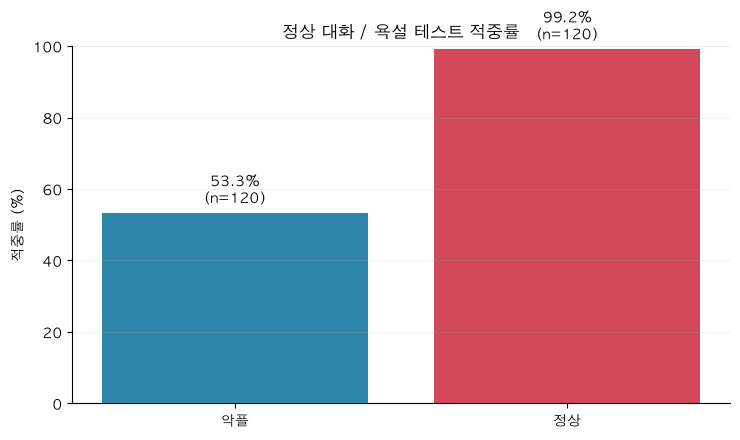

In [16]:
import ast
import random
import re
from collections import defaultdict
from urllib.request import urlopen

import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
from transformers import pipeline

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

PROFANITY_URL = "https://raw.githubusercontent.com/Tanat05/korean-profanity-resources/main/%EB%A6%AC%EA%B7%B8%EC%98%A4%EB%B8%8C%EB%A0%88%EC%A0%84%EB%93%9C_%ED%95%84%ED%84%B0%EB%A7%81%EB%A6%AC%EC%8A%A4%ED%8A%B8_2020.txt"
NORMAL_DATASET_NAME = "nayohan/141_korean_multi_session_dialogue"
OUTPUT_DIR = globals().get("OUTPUT_DIR", "./my-custom-model")
RANDOM_SEED = 42
PROFANITY_SAMPLE_LIMIT = 120
NORMAL_SAMPLE_LIMIT = 120

# 모델이 메모리에 없을 경우 대비해 다시 로드
try:
    classifier
except NameError:
    classifier = pipeline(
        "text-classification",
        model=OUTPUT_DIR,
        tokenizer=OUTPUT_DIR,
        top_k=None,
    )


def normalize_text(text: str) -> str:
    return " ".join(text.strip().split())


def canonical_label(label, model_id2label=None) -> str:
    if isinstance(label, str) and label.startswith("LABEL_"):
        label_index = int(label.split("_")[-1])
        if model_id2label and label_index in model_id2label:
            return model_id2label[label_index]
        return "정상" if label_index == 0 else "악플"
    if isinstance(label, int):
        if model_id2label and label in model_id2label:
            return model_id2label[label]
        return "정상" if label == 0 else "악플"
    return label


def load_profanity_words(url: str, limit: int) -> list[str]:
    raw_text = urlopen(url).read().decode("utf-8-sig", errors="ignore")
    words = []
    seen = set()

    for line in raw_text.splitlines():
        token = normalize_text(line)
        if not token:
            continue
        if token in {"...", "@!@"}:
            continue
        if not re.search(r"[가-힣A-Za-z0-9]", token):
            continue
        if token not in seen:
            seen.add(token)
            words.append(token)
        if len(words) >= limit:
            break

    return words


def collect_text_parts(value) -> list[str]:
    if isinstance(value, str):
        text = normalize_text(value)
        if not text:
            return []
        if (text.startswith("[") and text.endswith("]")) or (text.startswith("{") and text.endswith("}")):
            try:
                parsed = ast.literal_eval(text)
            except (ValueError, SyntaxError):
                return [text]
            return collect_text_parts(parsed)
        return [text]
    if isinstance(value, list):
        parts = []
        for item in value:
            parts.extend(collect_text_parts(item))
        return parts
    if isinstance(value, dict):
        parts = []
        for key, item in value.items():
            if key.lower() in {"id", "label", "speaker", "turn", "turn_id"}:
                continue
            parts.extend(collect_text_parts(item))
        return parts
    return []


def load_normal_texts(limit: int) -> list[str]:
    raw = load_dataset(NORMAL_DATASET_NAME)
    texts = []
    seen = set()

    for split_name in raw.keys():
        for example in raw[split_name]:
            for key, value in example.items():
                if key.lower() in {"id", "label", "speaker", "turn", "turn_id"}:
                    continue
                for text in collect_text_parts(value):
                    if len(text) < 2 or text in seen:
                        continue
                    seen.add(text)
                    texts.append(text)
                    if len(texts) >= limit:
                        return texts

    return texts


profanity_texts = load_profanity_words(PROFANITY_URL, PROFANITY_SAMPLE_LIMIT)
normal_texts = load_normal_texts(NORMAL_SAMPLE_LIMIT)

if not profanity_texts:
    raise ValueError("욕설 데이터셋을 불러오지 못했습니다.")

if not normal_texts:
    raise ValueError("정상 대화 데이터셋을 불러오지 못했습니다.")

model_id2label = getattr(getattr(classifier.model, "config", None), "id2label", {}) or {}

samples = []
for text in profanity_texts:
    samples.append((text, "악플", "욕설"))
for text in normal_texts:
    samples.append((text, "정상", "정상 대화"))

random.Random(RANDOM_SEED).shuffle(samples)

rows = []
summary = defaultdict(lambda: {"total": 0, "correct": 0})

for text, expected, source in samples:
    outputs = classifier(text, truncation=True, max_length=MAX_LENGTH)
    results = outputs[0] if outputs and isinstance(outputs[0], list) else outputs
    results = sorted(results, key=lambda item: item["score"], reverse=True)

    top = results[0]
    pred = canonical_label(top["label"], model_id2label)
    hit = "O" if pred == expected else "X"

    summary[expected]["total"] += 1
    if hit == "O":
        summary[expected]["correct"] += 1

    rows.append(
        {
            "문장": text,
            "출처": source,
            "정답": expected,
            "판정": pred,
            "점수": f"{top['score']:.4f}",
            "일치": hit,
        }
    )


df = pd.DataFrame(rows)
summary_df = pd.DataFrame(
    [
        {
            "라벨": label,
            "총개수": values["total"],
            "정답": values["correct"],
            "적중률": values["correct"] / values["total"] if values["total"] else 0,
        }
        for label, values in summary.items()
    ]
).sort_values("라벨")

overall_correct = int((df["일치"] == "O").sum())
overall_total = len(df)
overall_accuracy = overall_correct / overall_total if overall_total else 0

print(f"전체 적중률: {overall_correct}/{overall_total} ({overall_accuracy * 100:.1f}%)\n")
display(summary_df)
display(df.head(20))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars = ax.bar(summary_df["라벨"], summary_df["적중률"] * 100, color=["#2E86AB", "#D1495B"] )
ax.set_ylim(0, 100)
ax.set_ylabel("적중률 (%)")
ax.set_title("정상 대화 / 욕설 테스트 적중률")
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, rate, total in zip(bars, summary_df["적중률"], summary_df["총개수"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{rate * 100:.1f}%\n(n={total})",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

## 11. Gradio 웹 UI

학습 완료 후 바로 아래 셀을 실행하면 `http://127.0.0.1:7860` 에서 데모를 확인할 수 있습니다.

In [10]:
import gradio as gr
from transformers import pipeline

print(f"모델 로딩 중: {OUTPUT_DIR}")
classifier = pipeline(
    "text-classification",
    model=OUTPUT_DIR,
    tokenizer=OUTPUT_DIR,
    top_k=None,
)
print("모델 로딩 완료.")


def predict(text: str) -> str:
    """입력 채팅 문장에 대해 정상/악플 판정과 확률을 반환합니다."""
    if not text or not text.strip():
        return "텍스트를 입력해 주세요."

    results = sorted(classifier(text)[0], key=lambda x: x["score"], reverse=True)
    top = results[0]

    lines = [
        f"판정: {top['label']}",
        f"Score: {top['score']:.4f}",
        "",
        "전체 점수:",
    ]
    for item in results:
        lines.append(f"  - {item['label']}: {item['score']:.4f}")
    return "\n".join(lines)


demo = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(
        lines=3,
        label="게임 채팅 입력",
        placeholder="예: 오늘 한 판 더 할까? / 너 진짜 쓰레기네",
    ),
    outputs=gr.Textbox(label="분류 결과", lines=8),
    title="게임 채팅 악플 필터링 분류기",
    description=(
        "한국어 게임 채팅/댓글 문장을 입력하면 "
        "정상 또는 악플 여부와 확률(Score)을 출력합니다. "
        "(데이터: smilegate-ai/kor_unsmile, 모델: beomi/kcbert-base fine-tuned)"
    ),
    examples=[
        ["오늘 저녁에 랭크 한 판 어때?"],
        ["너 때문에 졌잖아 진짜 못하네"],
        ["ㅋㅋㅋ 개못하네 꺼져"],
        ["팀원들 수고했어 다음에도 같이 하자"],
    ],
)

# Colab 환경에서는 share=True 필수 - 자동으로 공개 링크(https://xxxx.gradio.live)가 생성됩니다
demo.launch(share=True)

모델 로딩 중: ./my-custom-model


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 24011.82it/s]


모델 로딩 완료.
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://69f6e883959f5745e0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 11. (선택) Hugging Face Hub 업로드

1. 터미널에서 `huggingface-cli login` 실행 후 **Write** 권한 토큰 입력
2. 아래 셀 주석 해제 후 `YOUR_HF_USERNAME`을 본인 계정명으로 변경

In [11]:
# from huggingface_hub import HfApi
#
# repo_id = "YOUR_HF_USERNAME/game-chat-abuse-filter"
# api = HfApi()
# api.upload_folder(
#     folder_path=OUTPUT_DIR,
#     repo_id=repo_id,
#     repo_type="model",
# )
# print(f"Hub 업로드 완료: https://huggingface.co/{repo_id}")